### **Hierarchical Indexing**


In [60]:
import pandas as pd
import numpy as np
import seaborn as sns


**The bad way** of multi indexed series


In [2]:
index = [
    ("California", 2000),
    ("California", 2010),
    ("New York", 2000),
    ("New York", 2010),
    ("Texas", 2000),
    ("Texas", 2010),
]
populations = [33871648, 37253956, 18976457, 19378102, 20851820, 25145561]
pop = pd.Series(populations, index=index)
pop


(California, 2000)    33871648
(California, 2010)    37253956
(New York, 2000)      18976457
(New York, 2010)      19378102
(Texas, 2000)         20851820
(Texas, 2010)         25145561
dtype: int64

In [3]:
pop[("California", 2010) : ("Texas", 2000)]


(California, 2010)    37253956
(New York, 2000)      18976457
(New York, 2010)      19378102
(Texas, 2000)         20851820
dtype: int64

In [4]:
pop.index[0][1]


2000

In [5]:
for i in pop.index:
    if i[1] == 2010:
        print(i[0], pop[i])


California 37253956
New York 19378102
Texas 25145561


In [6]:
pop[[i for i in pop.index if i[1] == 2000]]


(California, 2000)    33871648
(New York, 2000)      18976457
(Texas, 2000)         20851820
dtype: int64

In [7]:
pop


(California, 2000)    33871648
(California, 2010)    37253956
(New York, 2000)      18976457
(New York, 2010)      19378102
(Texas, 2000)         20851820
(Texas, 2010)         25145561
dtype: int64

In [8]:
print(pop[("California", 2000)])


33871648


In [9]:
pop[:, 2000]


KeyError: 'key of type tuple not found and not a MultiIndex'

**The Better Way:** Pandas MultiIndex


In [10]:
index = pd.MultiIndex.from_tuples(index)
index


MultiIndex([('California', 2000),
            ('California', 2010),
            (  'New York', 2000),
            (  'New York', 2010),
            (     'Texas', 2000),
            (     'Texas', 2010)],
           )

In [11]:
type(index)


pandas.MultiIndex

In [12]:
pop = pop.reindex(index)
pop


California  2000    33871648
            2010    37253956
New York    2000    18976457
            2010    19378102
Texas       2000    20851820
            2010    25145561
dtype: int64

In [13]:
pop["California", :]


2000    33871648
2010    37253956
dtype: int64

In [14]:
pop[:, 2000]


California    33871648
New York      18976457
Texas         20851820
dtype: int64

In [15]:
print(pop["California", 2000])


33871648


In [16]:
pop[("California", 2010) : ("Texas", 2000)]


California  2010    37253956
New York    2000    18976457
            2010    19378102
Texas       2000    20851820
dtype: int64

In [17]:
pop2 = pop.copy()
pop2.index.names = ["state", "year"]
pop2


state       year
California  2000    33871648
            2010    37253956
New York    2000    18976457
            2010    19378102
Texas       2000    20851820
            2010    25145561
dtype: int64

Explicit MultiIndex constructors


In [18]:
pd.MultiIndex.from_arrays([["a", "a", "b", "b"], [1, 2, 1, 2]])


MultiIndex([('a', 1),
            ('a', 2),
            ('b', 1),
            ('b', 2)],
           )

In [19]:
pd.MultiIndex.from_tuples([("a", 1), ("a", 2), ("b", 1), ("b", 2)])


MultiIndex([('a', 1),
            ('a', 2),
            ('b', 1),
            ('b', 2)],
           )

In [20]:
pd.MultiIndex.from_product([["a", "b", "c", "d"], range(1990, 1994)])


MultiIndex([('a', 1990),
            ('a', 1991),
            ('a', 1992),
            ('a', 1993),
            ('b', 1990),
            ('b', 1991),
            ('b', 1992),
            ('b', 1993),
            ('c', 1990),
            ('c', 1991),
            ('c', 1992),
            ('c', 1993),
            ('d', 1990),
            ('d', 1991),
            ('d', 1992),
            ('d', 1993)],
           )

### **Multi-Index DataFrame**


In [21]:
pd.DataFrame(pop, columns=["population"])


population
California 2000    33871648
           2010    37253956
New York   2000    18976457
           2010    19378102
Texas      2000    20851820
           2010    25145561

#### **Stacking vs Unstacking**


In [22]:
# from long to wide in Stata
pop_df = pop.unstack()
pop_df


,2000,2010
California,33871648,37253956
New York,18976457,19378102
Texas,20851820,25145561


In [23]:
pop_df2 = pop_df.stack()
pop_df2


California  2000    33871648
            2010    37253956
New York    2000    18976457
            2010    19378102
Texas       2000    20851820
            2010    25145561
dtype: int64

In [24]:
print(type(pop))
print(type(pop.unstack()))
print(type(pop.unstack().stack()))


<class 'pandas.Series'>
<class 'pandas.DataFrame'>
<class 'pandas.Series'>


In [25]:
pop_df = pd.DataFrame(
    {"total": pop, "under18": [9267089, 9284094, 4687374, 4318033, 5906301, 6879014]}
)
pop_df


total  under18
California 2000  33871648  9267089
           2010  37253956  9284094
New York   2000  18976457  4687374
           2010  19378102  4318033
Texas      2000  20851820  5906301
           2010  25145561  6879014

In [26]:
pop_df["f_u18"] = round((pop_df["under18"] / pop_df["total"]) * 100, 2)
pop_df


total  under18  f_u18
California 2000  33871648  9267089  27.36
           2010  37253956  9284094  24.92
New York   2000  18976457  4687374  24.70
           2010  19378102  4318033  22.28
Texas      2000  20851820  5906301  28.33
           2010  25145561  6879014  27.36

In [27]:
pop_df.unstack()


total            under18           f_u18       
                2000      2010     2000     2010   2000   2010
California  33871648  37253956  9267089  9284094  27.36  24.92
New York    18976457  19378102  4687374  4318033  24.70  22.28
Texas       20851820  25145561  5906301  6879014  28.33  27.36

In [28]:
pop_df.stack()


California  2000  total      33871648.00
                  under18     9267089.00
                  f_u18            27.36
            2010  total      37253956.00
                  under18     9284094.00
                  f_u18            24.92
New York    2000  total      18976457.00
                  under18     4687374.00
                  f_u18            24.70
            2010  total      19378102.00
                  under18     4318033.00
                  f_u18            22.28
Texas       2000  total      20851820.00
                  under18     5906301.00
                  f_u18            28.33
            2010  total      25145561.00
                  under18     6879014.00
                  f_u18            27.36
dtype: float64

In [29]:
pop.unstack(level=0)


,California,New York,Texas
2000,33871648,18976457,20851820
2010,37253956,19378102,25145561


In [30]:
pop.unstack(level=1)


,2000,2010
California,33871648,37253956
New York,18976457,19378102
Texas,20851820,25145561


In [31]:
pop


California  2000    33871648
            2010    37253956
New York    2000    18976457
            2010    19378102
Texas       2000    20851820
            2010    25145561
dtype: int64

In [32]:
pop_flat = pop.reset_index(name="population")
pop_flat


,level_0,level_1,population
0,California,2000,33871648
1,California,2010,37253956
2,New York,2000,18976457
3,New York,2010,19378102
4,Texas,2000,20851820
5,Texas,2010,25145561


In [33]:
pop_flat.set_index(["state", "year"])


KeyError: "None of ['state', 'year'] are in the columns"

### **Combining Datasets: Concat**


In [34]:
x = [1, 2, 3]
y = [4, 5, 6]
z = [7, 8, 9]
np.concatenate([x, y, z])


array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [35]:
# concatenate along the columns
x = [[1, 2], [3, 4]]
np.concatenate([x, x], axis=1)


array([[1, 2, 1, 2],
       [3, 4, 3, 4]])

In [36]:
# concatenate along the rows
np.concatenate([x, x], axis=0)


array([[1, 2],
       [3, 4],
       [1, 2],
       [3, 4]])

In [37]:
np.shape(x)


(2, 2)

In [38]:
ser1 = pd.Series(["A", "B", "C"], index=[1, 2, 3])
ser2 = pd.Series(["D", "E", "F"], index=[4, 5, 6])
pd.concat([ser1, ser2])


1    A
2    B
3    C
4    D
5    E
6    F
dtype: str

In [39]:
def make_df(cols, ind):
    """Quickly make a DataFrame"""
    data = {c: [str(c) + str(i) for i in ind] for c in cols}
    return pd.DataFrame(data, ind)


# example DataFrame
make_df("ABC", range(3))


,A,B,C
0,A0,B0,C0
1,A1,B1,C1
2,A2,B2,C2


In [40]:
# Different observations, same features
df1 = make_df("AB", [1, 2])
df2 = make_df("AB", [3, 4])
display(df1, df2, pd.concat([df1, df2], axis=0), pd.concat([df1, df2], axis=1))


,A,B
1,A1,B1
2,A2,B2


,A,B
3,A3,B3
4,A4,B4


,A,B
1,A1,B1
2,A2,B2
3,A3,B3
4,A4,B4


,A,B,A,B
1,A1,B1,NaN,NaN
2,A2,B2,NaN,NaN
3,NaN,NaN,A3,B3
4,NaN,NaN,A4,B4


In [41]:
# Different features, same observations (a more common case while working with real life data)
df3 = make_df("AB", [0, 1])
df4 = make_df("CD", [0, 1])
display(df3, df4, pd.concat([df3, df4], axis=0), pd.concat([df3, df4], axis=1))


,A,B
0,A0,B0
1,A1,B1


,C,D
0,C0,D0
1,C1,D1


,A,B,C,D
0,A0,B0,NaN,NaN
1,A1,B1,NaN,NaN
0,NaN,NaN,C0,D0
1,NaN,NaN,C1,D1


,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1


### **Merge and Join**


In [42]:
df1 = pd.DataFrame(
    {
        "employee": ["Bob", "Jake", "Lisa", "Sue"],
        "group": ["Accounting", "Engineering", "Engineering", "HR"],
    }
)
df2 = pd.DataFrame(
    {"employee": ["Lisa", "Bob", "Jake", "Sue"], "hire_date": [2004, 2008, 2012, 2014]}
)
display(df1, df2)


,employee,group
0,Bob,Accounting
1,Jake,Engineering
2,Lisa,Engineering
3,Sue,HR


,employee,hire_date
0,Lisa,2004
1,Bob,2008
2,Jake,2012
3,Sue,2014


In [43]:
df_temp = pd.concat([df1, df2], axis=1)
df_temp


,employee,group,employee,hire_date
0,Bob,Accounting,Lisa,2004
1,Jake,Engineering,Bob,2008
2,Lisa,Engineering,Jake,2012
3,Sue,HR,Sue,2014


In [44]:
# One-to-one
df3 = pd.merge(df1, df2)
df3

# The pd.merge() function recognizes that each DataFrame has an "employee" column, and automatically joins using this column as a key.


,employee,group,hire_date
0,Bob,Accounting,2008
1,Jake,Engineering,2012
2,Lisa,Engineering,2004
3,Sue,HR,2014


In [45]:
# Many-to-one
df4 = pd.DataFrame(
    {
        "group": ["Accounting", "Engineering", "HR"],
        "supervisor": ["Carly", "Guido", "Steve"],
    }
)
display(df3, df4, pd.merge(df3, df4))


,employee,group,hire_date
0,Bob,Accounting,2008
1,Jake,Engineering,2012
2,Lisa,Engineering,2004
3,Sue,HR,2014


,group,supervisor
0,Accounting,Carly
1,Engineering,Guido
2,HR,Steve


,employee,group,hire_date,supervisor
0,Bob,Accounting,2008,Carly
1,Jake,Engineering,2012,Guido
2,Lisa,Engineering,2004,Guido
3,Sue,HR,2014,Steve


In [46]:
# Many-to-many
df5 = pd.DataFrame(
    {
        "group": ["Accounting", "Accounting", "Engineering", "Engineering", "HR", "HR"],
        "skills": [
            "math",
            "spreadsheets",
            "coding",
            "linux",
            "spreadsheets",
            "organization",
        ],
    }
)
display(df1, df5, pd.merge(df1, df5))


,employee,group
0,Bob,Accounting
1,Jake,Engineering
2,Lisa,Engineering
3,Sue,HR


,group,skills
0,Accounting,math
1,Accounting,spreadsheets
2,Engineering,coding
3,Engineering,linux
4,HR,spreadsheets
5,HR,organization


,employee,group,skills
0,Bob,Accounting,math
1,Bob,Accounting,spreadsheets
2,Jake,Engineering,coding
3,Jake,Engineering,linux
4,Lisa,Engineering,coding
5,Lisa,Engineering,linux
6,Sue,HR,spreadsheets
7,Sue,HR,organization


### Specification of the Merge Key


In [47]:
display(df1, df2, pd.merge(df1, df2, on="employee"))


,employee,group
0,Bob,Accounting
1,Jake,Engineering
2,Lisa,Engineering
3,Sue,HR


,employee,hire_date
0,Lisa,2004
1,Bob,2008
2,Jake,2012
3,Sue,2014


,employee,group,hire_date
0,Bob,Accounting,2008
1,Jake,Engineering,2012
2,Lisa,Engineering,2004
3,Sue,HR,2014


In [48]:
df6 = pd.DataFrame({"name": ["Bob", "Jake", "Lisa", "Sue"], "rank": [1, 2, 3, 4]})
df7 = pd.DataFrame({"name": ["Bob", "Jake", "Lisa", "Sue"], "rank": [3, 1, 4, 2]})
display(df6, df7, pd.merge(df6, df7, on="rank"))


,name,rank
0,Bob,1
1,Jake,2
2,Lisa,3
3,Sue,4


,name,rank
0,Bob,3
1,Jake,1
2,Lisa,4
3,Sue,2


,name_x,rank,name_y
0,Bob,1,Jake
1,Jake,2,Sue
2,Lisa,3,Bob
3,Sue,4,Lisa


In [49]:
display(df6, df7, pd.merge(df6, df7, on="name", suffixes=["_speed", "_accuracy"]))


,name,rank
0,Bob,1
1,Jake,2
2,Lisa,3
3,Sue,4


,name,rank
0,Bob,3
1,Jake,1
2,Lisa,4
3,Sue,2


,name,rank_speed,rank_accuracy
0,Bob,1,3
1,Jake,2,1
2,Lisa,3,4
3,Sue,4,2


In [50]:
df8 = pd.DataFrame(
    {"name": ["Bob", "Jake", "Lisa", "Sue"], "salary": [70000, 80000, 120000, 90000]}
)
display(df1, df8, pd.merge(df1, df8, left_on="employee", right_on="name"))


,employee,group
0,Bob,Accounting
1,Jake,Engineering
2,Lisa,Engineering
3,Sue,HR


,name,salary
0,Bob,70000
1,Jake,80000
2,Lisa,120000
3,Sue,90000


,employee,group,name,salary
0,Bob,Accounting,Bob,70000
1,Jake,Engineering,Jake,80000
2,Lisa,Engineering,Lisa,120000
3,Sue,HR,Sue,90000


In [ ]:
pd.merge(df1, df8, left_on="employee", right_on="name").drop("name", axis=1)


,employee,group,salary
0,Bob,Accounting,70000
1,Jake,Engineering,80000
2,Lisa,Engineering,120000
3,Sue,HR,90000


In [ ]:
df1a = df1.set_index("employee")
df2a = df2.set_index("employee")
display(df1a, df2a)


,group
employee,
Bob,Accounting
Jake,Engineering
Lisa,Engineering
Sue,HR


,hire_date
employee,
Lisa,2004
Bob,2008
Jake,2012
Sue,2014


In [ ]:
display(df1a, df2, pd.merge(df1a, df2a, left_index=True, right_index=True))


,group
employee,
Bob,Accounting
Jake,Engineering
Lisa,Engineering
Sue,HR


,employee,hire_date
0,Lisa,2004
1,Bob,2008
2,Jake,2012
3,Sue,2014


,group,hire_date
employee,,
Bob,Accounting,2008
Jake,Engineering,2012
Lisa,Engineering,2004
Sue,HR,2014


In [ ]:
pd.merge(df1a, df2a, left_index=True, right_index=True).reset_index()


,employee,group,hire_date
0,Bob,Accounting,2008
1,Jake,Engineering,2012
2,Lisa,Engineering,2004
3,Sue,HR,2014


**Specifying Set Arithmetic for Joins**


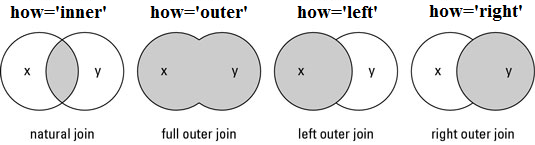


In [55]:
df9 = pd.DataFrame(
    {"name": ["Peter", "Paul", "Mary"], "food": ["fish", "beans", "bread"]},
    columns=["name", "food"],
)
df10 = pd.DataFrame(
    {"name": ["Mary", "Joseph"], "drink": ["wine", "beer"]}, columns=["name", "drink"]
)
display(df9, df10, pd.merge(df9, df10))


,name,food
0,Peter,fish
1,Paul,beans
2,Mary,bread


,name,drink
0,Mary,wine
1,Joseph,beer


,name,food,drink
0,Mary,bread,wine


In [ ]:
pd.merge(df9, df10, how="inner")


,name,food,drink
0,Mary,bread,wine


In [ ]:
display(df9, df10, pd.merge(df9, df10, how="outer"))


,name,food
0,Peter,fish
1,Paul,beans
2,Mary,bread


,name,drink
0,Mary,wine
1,Joseph,beer


,name,food,drink
0,Joseph,NaN,beer
1,Mary,bread,wine
2,Paul,beans,NaN
3,Peter,fish,NaN


In [ ]:
display(df9, df10, pd.merge(df9, df10, how="left"))


,name,food
0,Peter,fish
1,Paul,beans
2,Mary,bread


,name,drink
0,Mary,wine
1,Joseph,beer


,name,food,drink
0,Peter,fish,NaN
1,Paul,beans,NaN
2,Mary,bread,wine


In [ ]:
df11 = pd.DataFrame({"name": ["Bob", "Jake", "Lisa", "Sue"], "rank": [1, 2, 3, 4]})
df12 = pd.DataFrame({"name": ["Bob", "Jake", "Lisa", "Sue"], "rank": [3, 1, 4, 2]})
display(df11, df12, pd.merge(df11, df12, on="name"))


,name,rank
0,Bob,1
1,Jake,2
2,Lisa,3
3,Sue,4


,name,rank
0,Bob,3
1,Jake,1
2,Lisa,4
3,Sue,2


,name,rank_x,rank_y
0,Bob,1,3
1,Jake,2,1
2,Lisa,3,4
3,Sue,4,2


### **Aggregation and Grouping**

An essential piece of analysis of large data is efficient summarization: computing aggregations like `sum()`, `mean()`,
`median()`, `min()`, and `max()`, in which a single number gives insight into the nature of a potentially large dataset. In this
section, we'll explore aggregations in Pandas, from simple operations akin to what we've seen on NumPy arrays, to more
sophisticated operations based on the concept of a `groupby`.


In [ ]:
planets = sns.load_dataset("planets")
planets.shape


(1035, 6)

In [63]:
planets.head(10)


,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009
5,Radial Velocity,1,185.840,4.80,76.39,2008
6,Radial Velocity,1,1773.400,4.64,18.15,2002
7,Radial Velocity,1,798.500,NaN,21.41,1996
8,Radial Velocity,1,993.300,10.30,73.10,2008
9,Radial Velocity,2,452.800,1.99,74.79,2010


In [ ]:
rng = np.random.RandomState(42)
type(rng)


numpy.random.mtrand.RandomState

In [ ]:
ser = pd.Series(rng.rand(5))
ser


0    0.374540
1    0.950714
2    0.731994
3    0.598658
4    0.156019
dtype: float64

In [ ]:
print(ser.sum())


2.811925491708157


In [ ]:
print(ser.mean())


0.5623850983416314


In [ ]:
df = pd.DataFrame({"A": rng.rand(5), "B": rng.rand(5)})
df


,A,B
0,0.155995,0.020584
1,0.058084,0.969910
2,0.866176,0.832443
3,0.601115,0.212339
4,0.708073,0.181825


In [ ]:
df.mean()


A    0.477888
B    0.443420
dtype: float64

In [ ]:
df.mean(axis=1)  # instead of 'columns', just write 1


0    0.088290
1    0.513997
2    0.849309
3    0.406727
4    0.444949
dtype: float64

In [ ]:
planets.dropna().describe().T


,count,mean,std,min,25%,50%,75%,max
number,498.0,1.734940,1.175720,1.0000,1.00000,1.000,2.0000,6.0
orbital_period,498.0,835.778671,1469.128259,1.3283,38.27225,357.000,999.6000,17337.5
mass,498.0,2.509320,3.636274,0.0036,0.21250,1.245,2.8675,25.0
distance,498.0,52.068213,46.596041,1.3500,24.49750,39.940,59.3325,354.0
year,498.0,2007.377510,4.167284,1989.0000,2005.00000,2009.000,2011.0000,2014.0


**GroupBy: Split, Apply, Combine**


In [ ]:
df = pd.DataFrame(
    {"key": ["A", "B", "C", "A", "B", "C"], "data": range(6)}, columns=["key", "data"]
)
df


,key,data
0,A,0
1,B,1
2,C,2
3,A,3
4,B,4
5,C,5


In [ ]:
df.groupby("key")


In [ ]:
df.groupby("key").mean()


,data
key,
A,1.5
B,2.5
C,3.5


In [ ]:
planets.groupby("method")


In [ ]:
planets.groupby("method")["orbital_period"]


In [ ]:
print(planets["orbital_period"].median())


39.9795


In [ ]:
planets.groupby("method")["orbital_period"].median()


method
Astrometry                         631.180000
Eclipse Timing Variations         4343.500000
Imaging                          27500.000000
Microlensing                      3300.000000
Orbital Brightness Modulation        0.342887
Pulsar Timing                       66.541900
Pulsation Timing Variations       1170.000000
Radial Velocity                    360.200000
Transit                              5.714932
Transit Timing Variations           57.011000
Name: orbital_period, dtype: float64

In [ ]:
planets.groupby("method")["orbital_period"].describe()


,count,mean,std,min,25%,50%,75%,max
method,,,,,,,,
Astrometry,2.0,631.180000,544.217663,246.360000,438.770000,631.180000,823.590000,1016.000000
Eclipse Timing Variations,9.0,4751.644444,2499.130945,1916.250000,2900.000000,4343.500000,5767.000000,10220.000000
Imaging,12.0,118247.737500,213978.177277,4639.150000,8343.900000,27500.000000,94250.000000,730000.000000
Microlensing,7.0,3153.571429,1113.166333,1825.000000,2375.000000,3300.000000,3550.000000,5100.000000
Orbital Brightness Modulation,3.0,0.709307,0.725493,0.240104,0.291496,0.342887,0.943908,1.544929
Pulsar Timing,5.0,7343.021201,16313.265573,0.090706,25.262000,66.541900,98.211400,36525.000000
Pulsation Timing Variations,1.0,1170.000000,NaN,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000
Radial Velocity,553.0,823.354680,1454.926210,0.736540,38.021000,360.200000,982.000000,17337.500000
Transit,397.0,21.102073,46.185893,0.355000,3.160630,5.714932,16.145700,331.600590


**Aggregate, filter, transform, apply**


In [ ]:
rng = np.random.RandomState(0)
df = pd.DataFrame(
    {
        "key": ["A", "B", "C", "A", "B", "C"],
        "data1": range(6),
        "data2": rng.randint(0, 10, 6),
    },
    columns=["key", "data1", "data2"],
)
df


,key,data1,data2
0,A,0,5
1,B,1,0
2,C,2,3
3,A,3,3
4,B,4,7
5,C,5,9


In [ ]:
df.groupby("key").min()


,data1,data2
key,,
A,0,3
B,1,0
C,2,3


In [ ]:
df.groupby("key").aggregate([np.min, np.mean, np.max])


data1          data2         
      min mean max   min mean max
key                              
A       0  1.5   3     3  4.0   5
B       1  2.5   4     0  3.5   7
C       2  3.5   5     3  6.0   9

In [ ]:
# aggregation returns some reduced version of data
df.groupby("key").aggregate(["min", "mean", "max"])


data1          data2         
      min mean max   min mean max
key                              
A       0  1.5   3     3  4.0   5
B       1  2.5   4     0  3.5   7
C       2  3.5   5     3  6.0   9

In [ ]:
df.groupby("key").aggregate({"data1": "min", "data2": "max"})


,data1,data2
key,,
A,0,5
B,1,7
C,2,9


In [ ]:
def asd(x):
    return x["data2"].std() > 4


display(df, df.groupby("key").std(), df.groupby("key").filter(asd))


,key,data1,data2
0,A,0,5
1,B,1,0
2,C,2,3
3,A,3,3
4,B,4,7
5,C,5,9


,data1,data2
key,,
A,2.12132,1.414214
B,2.12132,4.949747
C,2.12132,4.242641


,key,data1,data2
1,B,1,0
2,C,2,3
4,B,4,7
5,C,5,9


While aggregation must return a reduced version of the data, transformation can return some transformed version of the full data
to recombine. For such a transformation, the output is the same shape as the input. A common example is to center the data by
subtracting the group-wise mean:


In [90]:
##transformation returns transformed version of data

display(
    df, df.groupby("key").mean(), df.groupby("key").transform(lambda x: x - x.mean())
)


,key,data1,data2
0,A,0,5
1,B,1,0
2,C,2,3
3,A,3,3
4,B,4,7
5,C,5,9


,data1,data2
key,,
A,1.5,4.0
B,2.5,3.5
C,3.5,6.0


,data1,data2
0,-1.5,1.0
1,-1.5,-3.5
2,-1.5,-3.0
3,1.5,-1.0
4,1.5,3.5
5,1.5,3.0


A lambda function in python is a small anonymous function that can take any number of arguments and execute an expression.


In [95]:
print(df["data2"].sum())


27


In [97]:
df_revised = df.groupby("key").transform(lambda x: x - x.mean())
df_revised


,data1,data2
0,-1.5,1.0
1,-1.5,-3.5
2,-1.5,-3.0
3,1.5,-1.0
4,1.5,3.5
5,1.5,3.0


In [ ]:
def norm_by_data2(x):
    # x is a DataFrame of group values
    x["data1"] = x["data1"] / x["data2"].sum()
    return x


display(df, df.groupby("key").apply(norm_by_data2))


,key,data1,data2
0,A,0,5
1,B,1,0
2,C,2,3
3,A,3,3
4,B,4,7
5,C,5,9


data1  data2
key                   
A   0  0.000000      5
    3  0.375000      3
B   1  0.142857      0
    4  0.571429      7
C   2  0.166667      3
    5  0.416667      9

In [105]:
rng = np.random.RandomState(0)
df = pd.DataFrame(
    {
        "key": ["A", "B", "C", "A", "B", "C"],
        "data1": range(6),
        "data2": rng.randint(0, 10, 6),
    },
    columns=["key", "data1", "data2"],
)
df


,key,data1,data2
0,A,0,5
1,B,1,0
2,C,2,3
3,A,3,3
4,B,4,7
5,C,5,9


In [106]:
L = [0, 1, 0, 1, 1, 0]
display(df, df.groupby(L).sum())


,key,data1,data2
0,A,0,5
1,B,1,0
2,C,2,3
3,A,3,3
4,B,4,7
5,C,5,9


,key,data1,data2
0,ACC,7,17
1,BAB,8,10


In [107]:
display(df, df.groupby(L).sum())


,key,data1,data2
0,A,0,5
1,B,1,0
2,C,2,3
3,A,3,3
4,B,4,7
5,C,5,9


,key,data1,data2
0,ACC,7,17
1,BAB,8,10


In [ ]:
df2 = df.set_index("key")
mapping = {"A": "vowel", "B": "consonant", "C": "consonant"}
display(df2, df2.groupby(mapping).sum())


,data1,data2
key,,
A,0,5
B,1,0
C,2,3
A,3,3
B,4,7
C,5,9


,data1,data2
key,,
consonant,12,19
vowel,3,8


In [ ]:
display(df2, df2.groupby(str.lower).mean())


,data1,data2
key,,
A,0,5
B,1,0
C,2,3
A,3,3
B,4,7
C,5,9


,data1,data2
key,,
a,1.5,4.0
b,2.5,3.5
c,3.5,6.0


In [ ]:
df2.groupby([str.lower, mapping]).mean()


,,data1,data2
key,key,,
a,vowel,1.5,4.0
b,consonant,2.5,3.5
c,consonant,3.5,6.0


In [ ]:
pop


California  2000    33871648
            2010    37253956
New York    2000    18976457
            2010    19378102
Texas       2000    20851820
            2010    25145561
dtype: int64

In [113]:
pop.groupby().mean()


TypeError: You have to supply one of 'by' and 'level'

In [ ]:
pop.groupby(level="year").mean()


#### **Grouping example**

As an example of this, in a couple lines of Python code we can put all these together and count discovered planets by method and
by decade:


In [ ]:
planets


,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300000,7.10,77.40,2006
1,Radial Velocity,1,874.774000,2.21,56.95,2008
2,Radial Velocity,1,763.000000,2.60,19.84,2011
3,Radial Velocity,1,326.030000,19.40,110.62,2007
4,Radial Velocity,1,516.220000,10.50,119.47,2009
...,...,...,...,...,...,...
1030,Transit,1,3.941507,NaN,172.00,2006
1031,Transit,1,2.615864,NaN,148.00,2007
1032,Transit,1,3.191524,NaN,174.00,2007
1033,Transit,1,4.125083,NaN,293.00,2008


In [ ]:
decade = 10 * (planets["year"] // 10)  # rounded down to the nearest whole number


In [ ]:
decade = decade.astype(str) + "s"
decade


0       2000s
1       2000s
2       2010s
3       2000s
4       2000s
        ...  
1030    2000s
1031    2000s
1032    2000s
1033    2000s
1034    2000s
Name: year, Length: 1035, dtype: str

In [117]:
type(decade)


pandas.Series

In [ ]:
planets["decade"] = decade
planets


,method,number,orbital_period,mass,distance,year,decade
0,Radial Velocity,1,269.300000,7.10,77.40,2006,2000s
1,Radial Velocity,1,874.774000,2.21,56.95,2008,2000s
2,Radial Velocity,1,763.000000,2.60,19.84,2011,2010s
3,Radial Velocity,1,326.030000,19.40,110.62,2007,2000s
4,Radial Velocity,1,516.220000,10.50,119.47,2009,2000s
...,...,...,...,...,...,...,...
1030,Transit,1,3.941507,NaN,172.00,2006,2000s
1031,Transit,1,2.615864,NaN,148.00,2007,2000s
1032,Transit,1,3.191524,NaN,174.00,2007,2000s
1033,Transit,1,4.125083,NaN,293.00,2008,2000s


In [ ]:
planets.groupby("method")["number"].sum()


method
Astrometry                         2
Eclipse Timing Variations         15
Imaging                           50
Microlensing                      27
Orbital Brightness Modulation      5
Pulsar Timing                     11
Pulsation Timing Variations        1
Radial Velocity                  952
Transit                          776
Transit Timing Variations          9
Name: number, dtype: int64

In [ ]:
planets.groupby(["method", "decade"])["number"].sum()


method                         decade
Astrometry                     2010s       2
Eclipse Timing Variations      2000s       5
                               2010s      10
Imaging                        2000s      29
                               2010s      21
Microlensing                   2000s      12
                               2010s      15
Orbital Brightness Modulation  2010s       5
Pulsar Timing                  1990s       9
                               2000s       1
                               2010s       1
Pulsation Timing Variations    2000s       1
Radial Velocity                1980s       1
                               1990s      52
                               2000s     475
                               2010s     424
Transit                        2000s      64
                               2010s     712
Transit Timing Variations      2010s       9
Name: number, dtype: int64

In [ ]:
planets.groupby(["method", "decade"])["number"].sum().unstack(level=1)


decade,1980s,1990s,2000s,2010s
method,,,,
Astrometry,NaN,NaN,NaN,2.0
Eclipse Timing Variations,NaN,NaN,5.0,10.0
Imaging,NaN,NaN,29.0,21.0
Microlensing,NaN,NaN,12.0,15.0
Orbital Brightness Modulation,NaN,NaN,NaN,5.0
Pulsar Timing,NaN,9.0,1.0,1.0
Pulsation Timing Variations,NaN,NaN,1.0,NaN
Radial Velocity,1.0,52.0,475.0,424.0
Transit,NaN,NaN,64.0,712.0


In [ ]:
planets.groupby(["method", decade])["number"].sum().unstack().fillna(0)


year,1980s,1990s,2000s,2010s
method,,,,
Astrometry,0.0,0.0,0.0,2.0
Eclipse Timing Variations,0.0,0.0,5.0,10.0
Imaging,0.0,0.0,29.0,21.0
Microlensing,0.0,0.0,12.0,15.0
Orbital Brightness Modulation,0.0,0.0,0.0,5.0
Pulsar Timing,0.0,9.0,1.0,1.0
Pulsation Timing Variations,0.0,0.0,1.0,0.0
Radial Velocity,1.0,52.0,475.0,424.0
Transit,0.0,0.0,64.0,712.0
